# Subject-vs-Stress Disentanglement Audit for SASContrast

**Question this notebook answers:** UMAP shows COMET clusters tightly by
subject identity yet performs worst on stress classification — i.e. its
representation encodes *who* rather than *how stressed*. Does SASContrast's
subject-specific branch (`z_spec`) run the same risk? And is there
distribution overlap / confounding between stress labels and subject
identity to begin with (which would make *any* method look subject-biased,
regardless of what it learned)?

This notebook reuses the checkpoint-loading / dataset-loading / embedding
utilities from
[`analysis/subject_stress_knn_analysis.py`](../analysis/subject_stress_knn_analysis.py)
(a standalone script written earlier in this investigation — see it for the
raw k-NN purity/accuracy numbers) and adds:

1. **Data-level confound check** — is subject identity statistically
   entangled with stress label *in the raw dataset*, independent of any
   model? (crosstab, Cramér's V, NMI)
2. **UMAP panels** — label-colored vs. subject-colored, for `z_inv`,
   `z_spec`, `h_out`, and a **random-init** baseline (same architecture,
   untrained weights) — matching the panel layout in the reference figure.
3. **Clustering metrics** — KMeans ARI/NMI against subject ID *and* against
   stress label, per head.
4. **k-NN purity** — same-subject vs. same-stress neighbour purity, per head.
5. **Matched-pair entanglement test** — for each anchor point, is a
   same-subject/different-stress neighbour closer than a
   different-subject/same-stress neighbour? This isolates *representation*
   entanglement from *data* confounding (unlike raw purity, which conflates
   the two).

All embeddings are extracted from **de-duplicated, non-overlapping windows**
(WESAD windows overlap 95%, SWELL 75% — see the script docstring). Skipping
this step trivially inflates every "purity"/"clustering" number because
nearest neighbours become near-duplicate windows of the same recording,
regardless of what the encoder learned.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from scipy.stats import chi2_contingency, binomtest

REPO_ROOT = "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from models.net.moe_encoder import MoEDualBranchEncoder
from analysis.subject_stress_knn_analysis import (
    RUNS, load_encoder, load_eval_dataset, extract_embeddings,
    empirical_chance_purity, majority_class_baseline, knn_purity_and_accuracy,
)

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cpu


## 1. Configuration ← edit here

`RUNS` (imported above) is the list of `(run_name, pretrain_dir, eval_dataset_name)`
combos already validated in `analysis/subject_stress_knn_analysis.py`:
SWELL-pretrained → eval WESAD, PsychioNet-pretrained → eval WESAD,
PsychioNet-pretrained → eval SWELL. Comment any out below to focus the run.

In [2]:
HEADS = ["z_inv", "z_spec", "h_out"]   # z_inv / h_out kept as contrast to z_spec

N_NEIGHBORS  = 15      # UMAP
MIN_DIST     = 0.1
RANDOM_STATE = 42

K_LIST       = [1, 5, 10, 20]   # k-NN purity/accuracy
N_ANCHORS    = 400              # matched-pair test sample size (per run/head)

OUTPUT_DIR = os.path.join(REPO_ROOT, "analysis", "subject_stress_disentanglement_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

for run_name, pretrain_dir, eval_dataset_name in RUNS:
    print(run_name, "->", eval_dataset_name)


WESAD-pretrained -> eval WESAD -> WESADDataset
SWELL-pretrained -> eval SWELL -> SWELLDataset
SWELL-pretrained -> eval WESAD -> WESADDataset
PsychioNet-pretrained -> eval WESAD -> WESADDataset
PsychioNet-pretrained -> eval SWELL -> SWELLDataset


## 2. Load encoders, de-duplicated datasets, and extract embeddings

Also builds a **random-init** encoder (same architecture, untrained) per run
as a baseline — if a random, never-trained encoder already clusters by
subject, that tells you the effect is coming from the raw signal statistics
(e.g. skin conductance baseline level, sensor placement), not from anything
the contrastive objective taught it.

In [3]:
import json

def create_random_encoder(pretrain_dir, device):
    '''Untrained encoder with the same architecture used for `pretrain_dir`'s checkpoint.'''
    with open(os.path.join(pretrain_dir, "pretrain", "config.json")) as f:
        cfg = json.load(f)
    enc_args = cfg["pretrain_args"]["model_args"]["base_encoder_args"]
    encoder = MoEDualBranchEncoder(
        input_dim=enc_args["input_dim"],
        dropout_prob=0.0,
        kernel_size=enc_args["kernel_size"],
        stride=enc_args["stride"],
        output_dim=enc_args["output_dim"],
        projection_output=enc_args["projection_output"],
    ).to(device)
    encoder.eval()
    return encoder


run_data = {}  # run_name -> dict(subj=, label=, z_inv=, z_spec=, h_out=,
               #                  z_inv_rand=, z_spec_rand=, h_out_rand=)

for run_name, pretrain_dir, eval_dataset_name in RUNS:
    print(f"\\n=== {run_name} ===")
    encoder = load_encoder(pretrain_dir, DEVICE)
    loader = load_eval_dataset(eval_dataset_name, dedup_overlap=True)
    emb = extract_embeddings(encoder, loader, DEVICE)

    rand_encoder = create_random_encoder(pretrain_dir, DEVICE)
    # reuse the SAME loader/order so subj/label line up 1:1 with `emb`
    loader_rand = load_eval_dataset(eval_dataset_name, dedup_overlap=True)
    emb_rand = extract_embeddings(rand_encoder, loader_rand, DEVICE)

    run_data[run_name] = {
        "eval_dataset": eval_dataset_name,
        "subj": emb["subj"], "label": emb["label"],
        "z_inv": emb["z_inv"], "z_spec": emb["z_spec"], "h_out": emb["h_out"],
        "z_inv_rand": emb_rand["z_inv"], "z_spec_rand": emb_rand["z_spec"],
        "h_out_rand": emb_rand["h_out"],
    }
    print(f"  N={len(emb['subj'])}  subjects={len(np.unique(emb['subj']))}")


\n=== WESAD-pretrained -> eval WESAD ===



  0%|          | 0/15 [00:00<?, ?it/s]


  7%|▋         | 1/15 [00:01<00:14,  1.03s/it]


 13%|█▎        | 2/15 [00:01<00:09,  1.42it/s]


 20%|██        | 3/15 [00:01<00:06,  1.88it/s]

...


 92%|█████████▏| 23/25 [00:08<00:00,  5.12it/s]


100%|██████████| 25/25 [00:08<00:00,  6.45it/s]


100%|██████████| 25/25 [00:08<00:00,  2.95it/s]

sub sample frac is None

=== Label Statistics ===
Label 0 count: 20227 = 39.11%
Label 1 count: 31487 = 60.89%

=== Subject Statistics ===
Total subjects: 25

=== Samples Per Subject ===
  Subject s10_phsyio.pkl: 2335 samples (4.5% of total)
  Subject s11_phsyio.pkl: 784 samples (1.5% of total)
  Subject s12_phsyio.pkl: 2577 samples (5.0% of total)
  Subject s13_phsyio.pkl: 2257 samples (4.4% of total)
  Subject s14_phsyio.pkl: 2567 samples (5.0% of total)
  Subject s15_phsyio.pkl: 2210 samples (4.3% of total)
  Subject s16_phsyio.pkl: 2579 samples (5.0% of total)
  Subject s17_phsyio.pkl: 2578 samples (5.0% of total)
  Subject s18_phsyio.pkl: 2338 samples (4.5% of total)
  Subject s19_phsyio.pkl: 2379 samples (4.6% of total)
  Subject s1_phsyio.pkl: 2563 samples (5.0% of total)
  Subject s20_phsyio.pkl: 1644 samples (3.2% of total)
  Subject s21_phsyio.pkl: 2026 samples (3.9% of total)
  Subject s22_phsyio.pkl: 1611 samples (3.1% of total)
  Subject s23_phsyio.pkl: 620 samples (1.2% of

  N=12938  subjects=25


## 3. Data-level confound check

Before blaming the *representation* for entangling subject and stress, check
whether the *raw dataset* already entangles them (e.g. if some subjects only
ever appear in the stress condition due to a protocol quirk, any encoder —
even a random one — would show subject clusters that look "stress-pure").

- **Cramér's V** — 0 = no association, 1 = perfect association between
  subject ID and stress label.
- **NMI(subject, stress)** — normalized mutual information between the two
  label columns themselves (not embeddings).

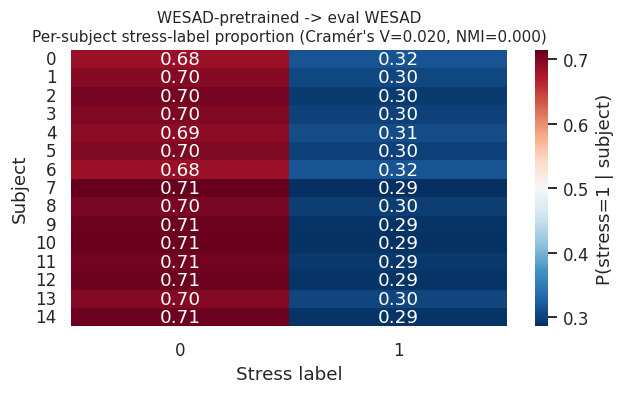

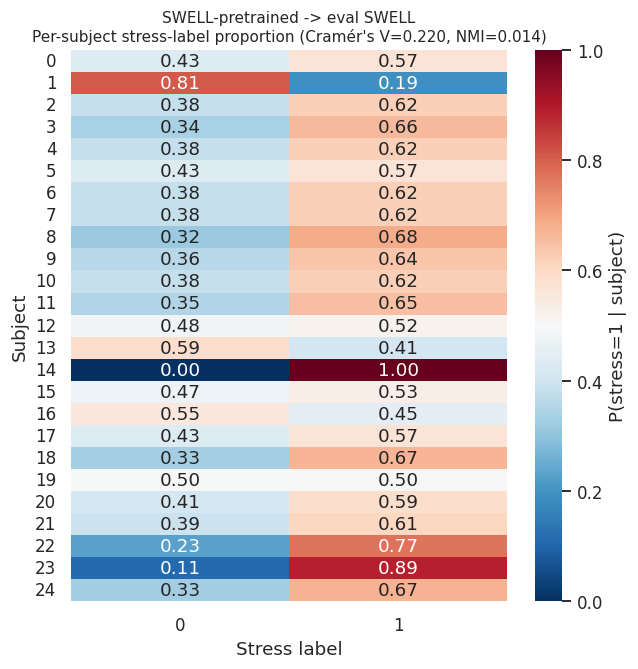

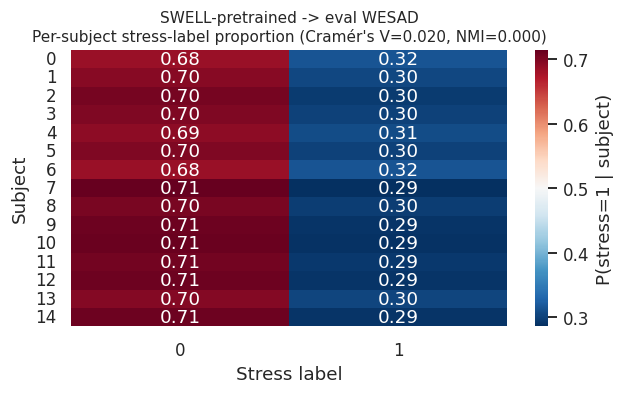

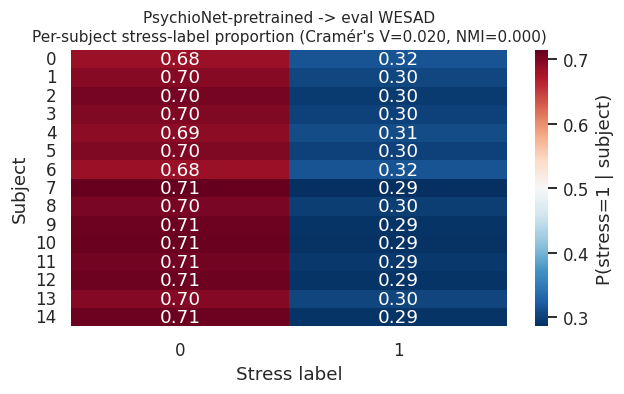

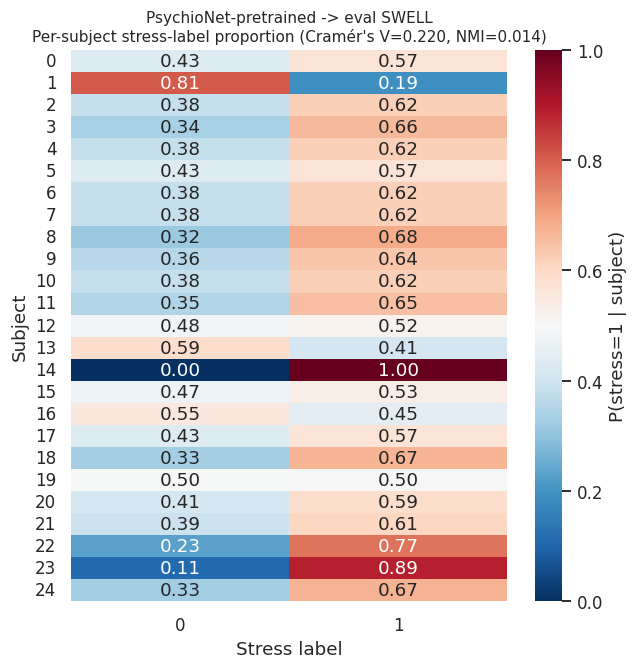

,run,eval_dataset,cramers_v_subject_stress,nmi_subject_stress,chi2_p_value
0,WESAD-pretrained -> eval WESAD,WESADDataset,0.02,0.0001,9.999938e-01
1,SWELL-pretrained -> eval SWELL,SWELLDataset,0.22,0.0141,3.007448e-117
2,SWELL-pretrained -> eval WESAD,WESADDataset,0.02,0.0001,9.999938e-01
3,PsychioNet-pretrained -> eval WESAD,WESADDataset,0.02,0.0001,9.999938e-01
4,PsychioNet-pretrained -> eval SWELL,SWELLDataset,0.22,0.0141,3.007448e-117


In [4]:
confound_rows = []
for run_name, rd in run_data.items():
    subj, label = rd["subj"], rd["label"]
    ct = pd.crosstab(subj, label, normalize="index")
    chi2, p, dof, _ = chi2_contingency(pd.crosstab(subj, label))
    n = len(subj)
    r_, c_ = pd.crosstab(subj, label).shape
    cramers_v = np.sqrt((chi2 / n) / (min(r_ - 1, c_ - 1)))
    nmi = normalized_mutual_info_score(subj, label)
    confound_rows.append({
        "run": run_name, "eval_dataset": rd["eval_dataset"],
        "cramers_v_subject_stress": round(cramers_v, 3),
        "nmi_subject_stress": round(nmi, 4),
        "chi2_p_value": p,
    })

    fig, ax = plt.subplots(figsize=(6, max(3, 0.25 * len(ct))))
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="RdBu_r", center=0.5,
                cbar_kws={"label": "P(stress=1 | subject)"}, ax=ax)
    ax.set_title(f"{run_name}\nPer-subject stress-label proportion "
                 f"(Cramér's V={cramers_v:.3f}, NMI={nmi:.3f})", fontsize=10)
    ax.set_xlabel("Stress label"); ax.set_ylabel("Subject")
    plt.tight_layout()
    safe = run_name.replace(" ", "_").replace(">", "to").replace("-", "_")
    fig.savefig(os.path.join(OUTPUT_DIR, f"{safe}_confound_heatmap.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

confound_df = pd.DataFrame(confound_rows)
confound_df.to_csv(os.path.join(OUTPUT_DIR, "data_confound.csv"), index=False)
confound_df


**How to read this:** a low Cramér's V / NMI (near 0) means every subject
shows roughly the same stress/baseline mix — i.e. subject and stress are
*not* confounded in the data, so any subject-purity you see later is a
genuine property of the representation, not something inherited from
lopsided protocol design. A high value means the dataset itself makes
subject and stress hard to tell apart, and downstream "subject clustering"
findings need that caveat.

## 4. UMAP — label-colored vs. subject-colored, per head

Same panel layout as the reference figure: one row colored by stress label,
one row colored by subject ID, one column per head (`z_inv`, `z_spec`,
`h_out`) plus the random-init baseline for comparison.

[WESAD-pretrained -> eval WESAD] UMAP fit: z_inv


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[WESAD-pretrained -> eval WESAD] UMAP fit: z_spec


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[WESAD-pretrained -> eval WESAD] UMAP fit: h_out


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[WESAD-pretrained -> eval WESAD] UMAP fit: h_out_rand


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))


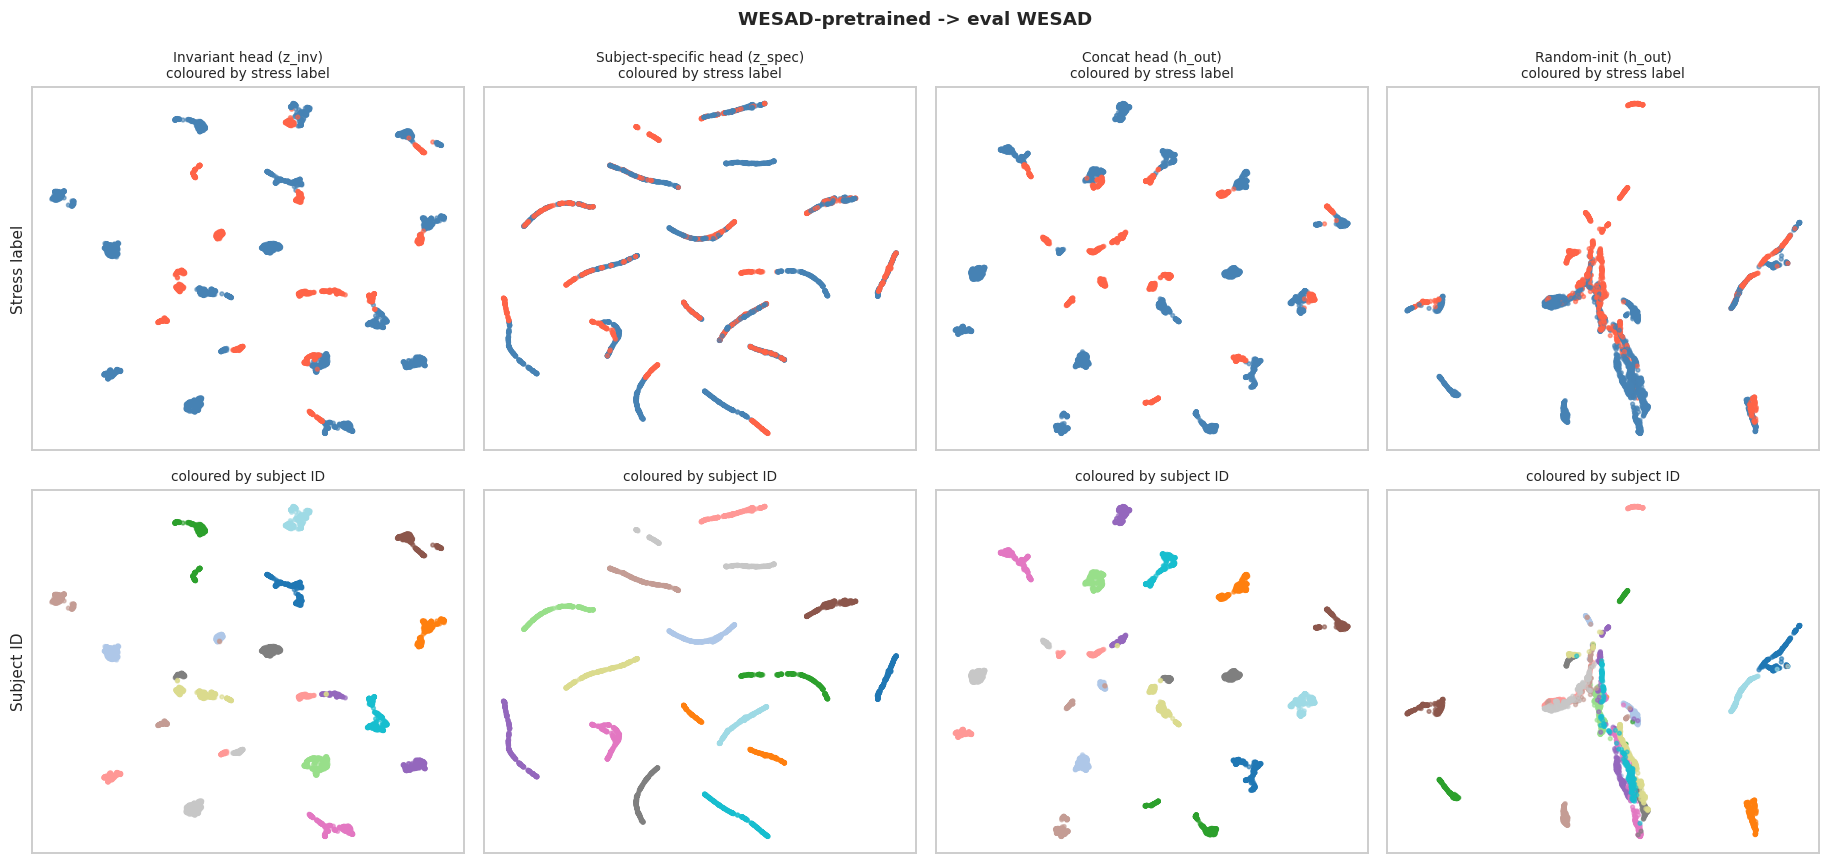

[SWELL-pretrained -> eval SWELL] UMAP fit: z_inv


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SWELL-pretrained -> eval SWELL] UMAP fit: z_spec


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SWELL-pretrained -> eval SWELL] UMAP fit: h_out


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SWELL-pretrained -> eval SWELL] UMAP fit: h_out_rand


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))


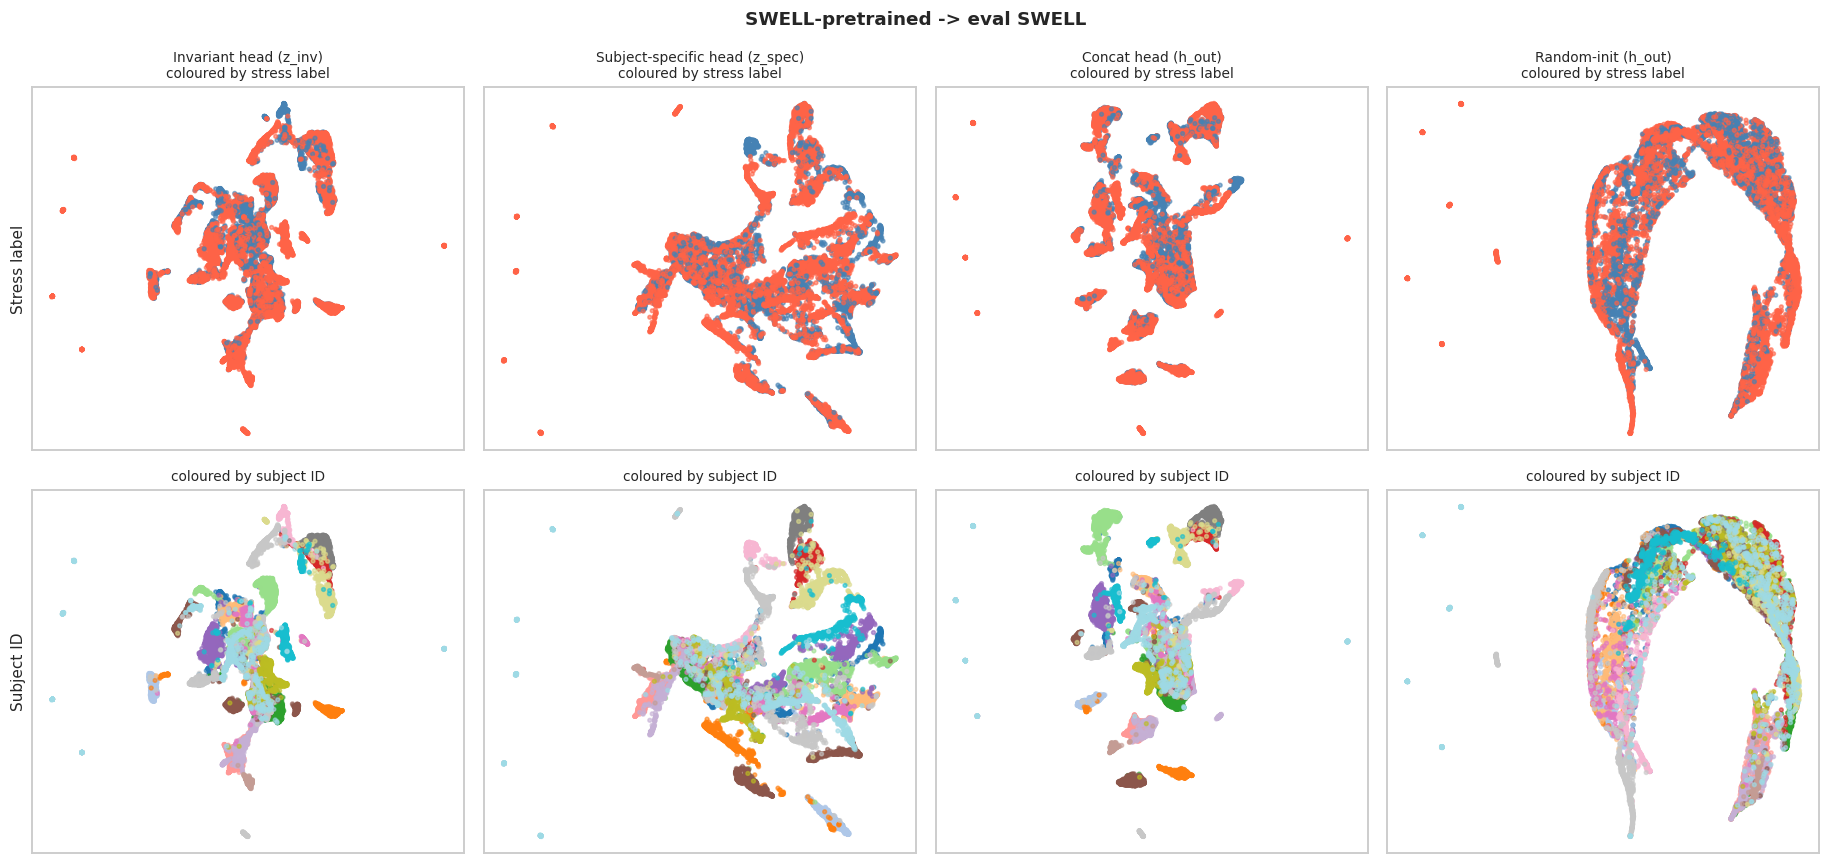

[SWELL-pretrained -> eval WESAD] UMAP fit: z_inv


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SWELL-pretrained -> eval WESAD] UMAP fit: z_spec


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SWELL-pretrained -> eval WESAD] UMAP fit: h_out


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SWELL-pretrained -> eval WESAD] UMAP fit: h_out_rand


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))


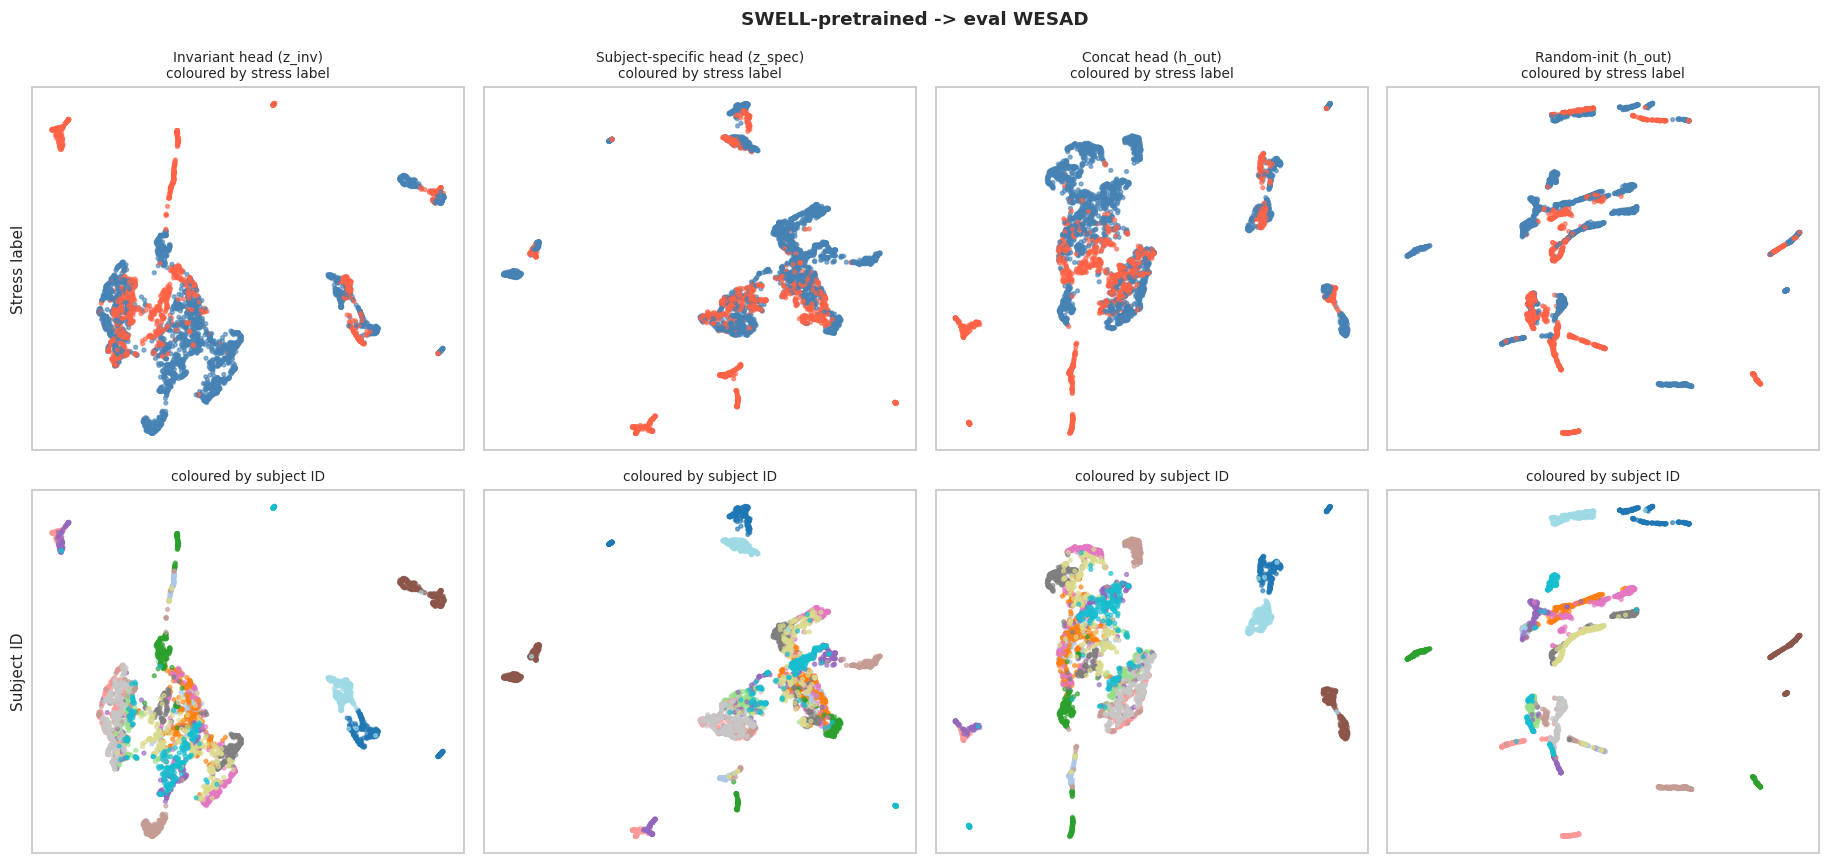

[PsychioNet-pretrained -> eval WESAD] UMAP fit: z_inv


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[PsychioNet-pretrained -> eval WESAD] UMAP fit: z_spec


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[PsychioNet-pretrained -> eval WESAD] UMAP fit: h_out


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[PsychioNet-pretrained -> eval WESAD] UMAP fit: h_out_rand


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))


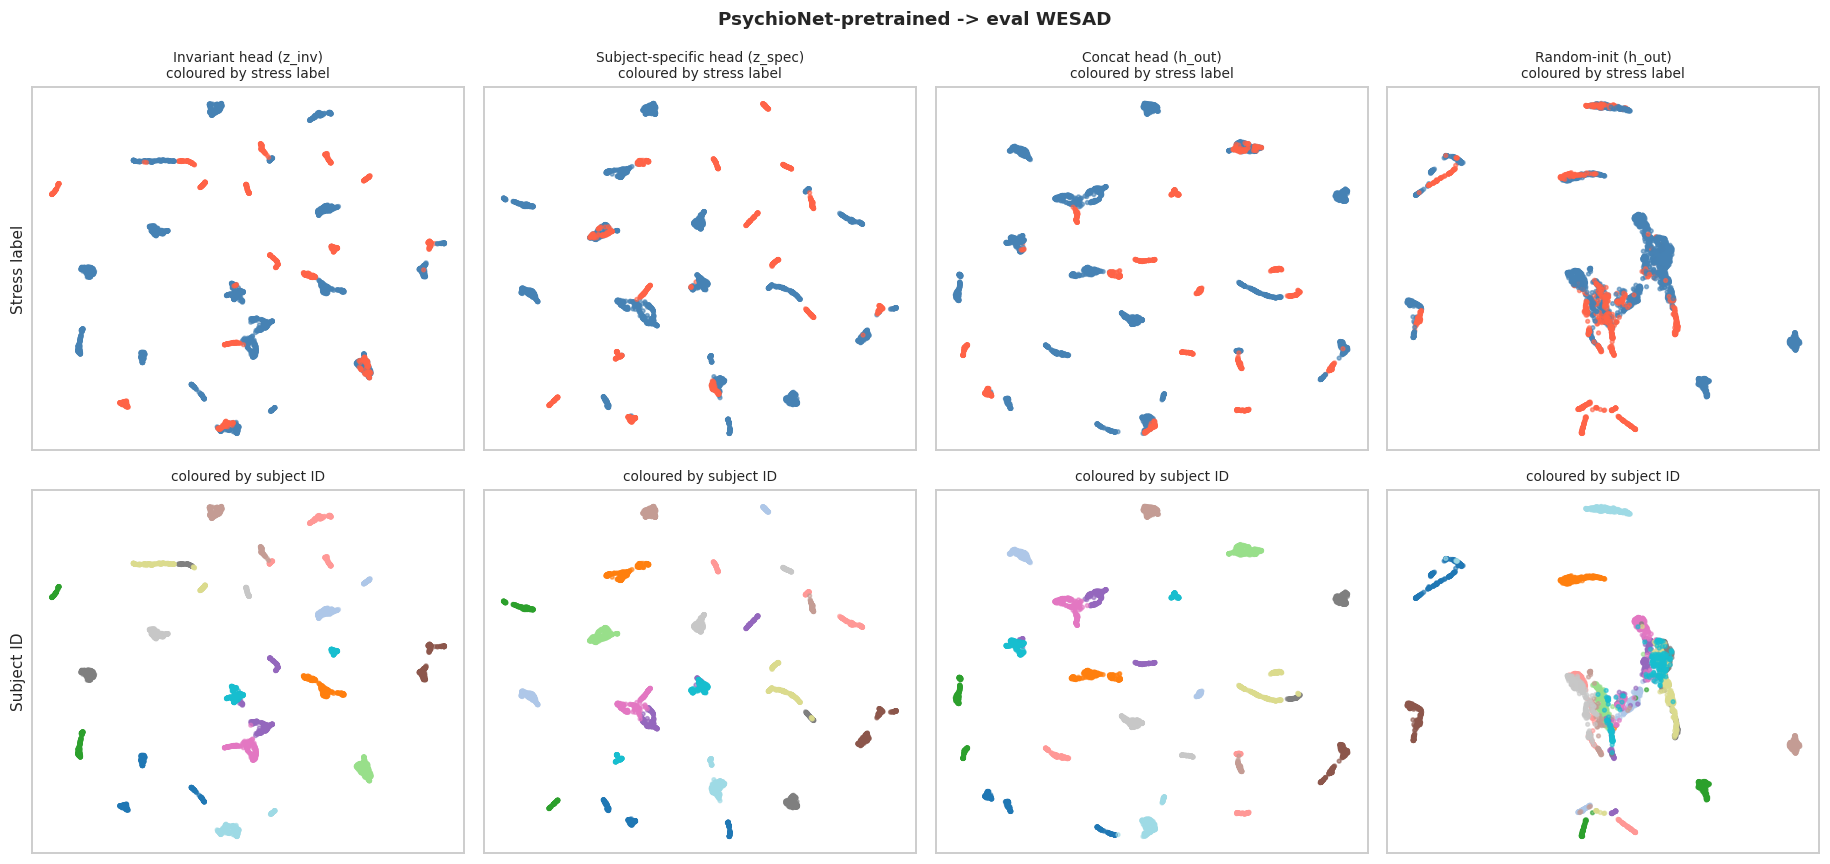

[PsychioNet-pretrained -> eval SWELL] UMAP fit: z_inv


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[PsychioNet-pretrained -> eval SWELL] UMAP fit: z_spec


...

[PsychioNet-pretrained -> eval SWELL] UMAP fit: h_out


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[PsychioNet-pretrained -> eval SWELL] UMAP fit: h_out_rand


/tmp/ipykernel_3056770/2328888901.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique))


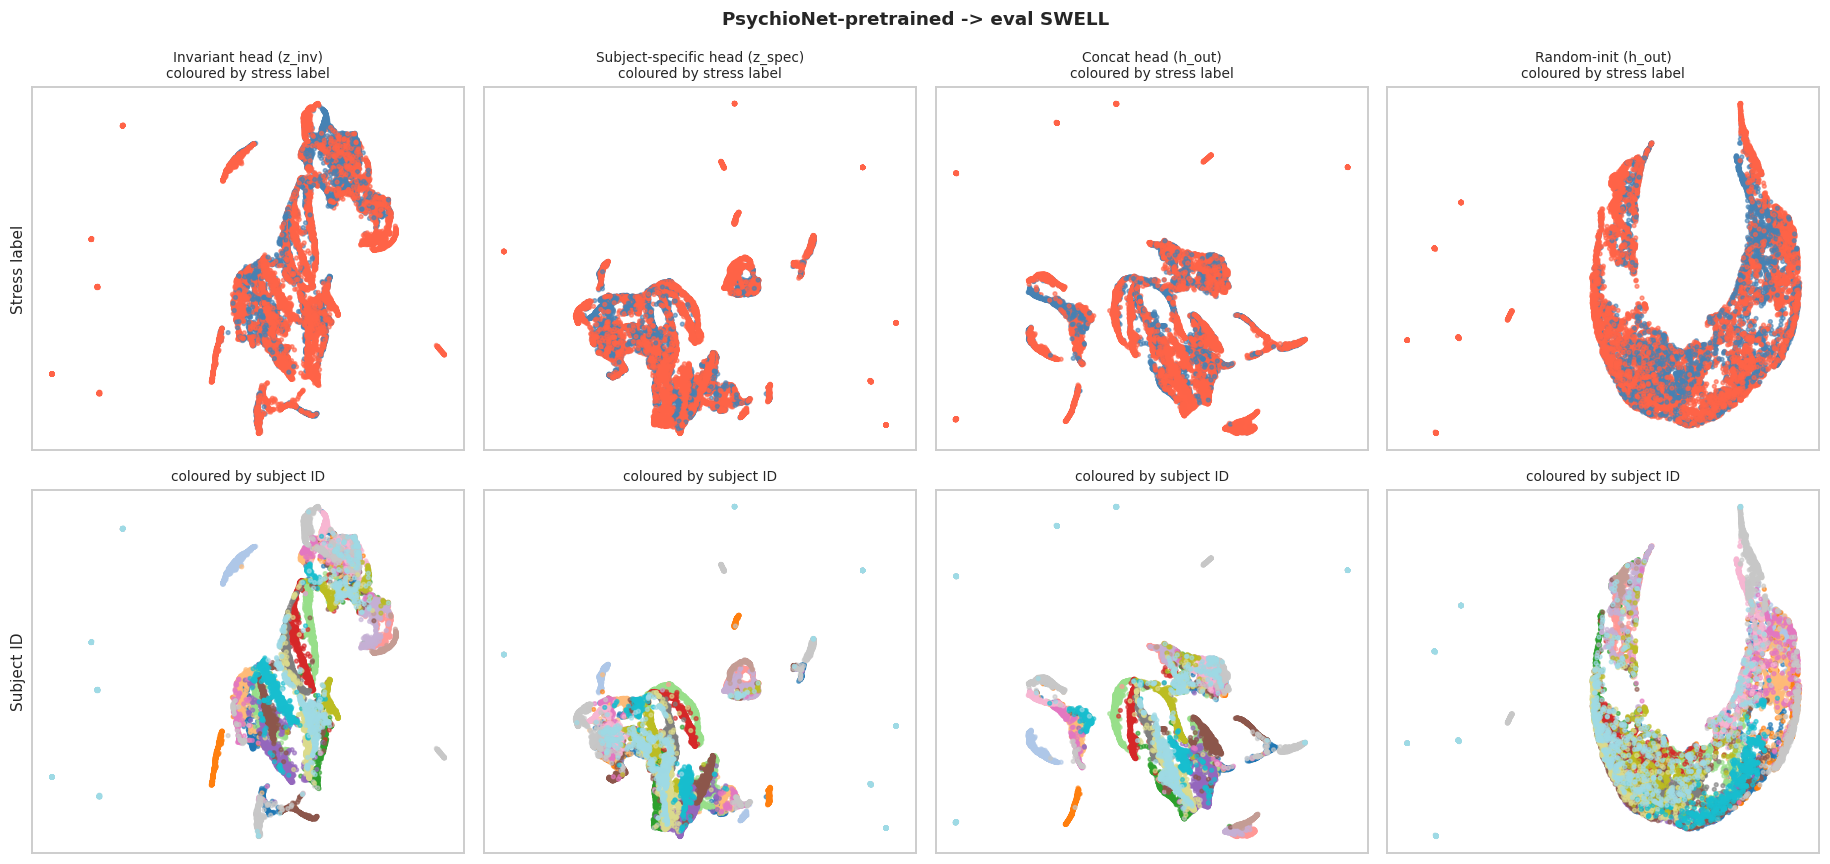

In [5]:
def cmap_colors(ids, cmap_name="tab20"):
    unique = np.unique(ids)
    cmap = cm.get_cmap(cmap_name, len(unique))
    id_to_color = {uid: cmap(i) for i, uid in enumerate(unique)}
    return np.array([id_to_color[i] for i in ids]), unique, cmap


def fit_umap(x):
    return umap.UMAP(n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST,
                      random_state=RANDOM_STATE, n_components=2).fit_transform(x)


PANEL_HEADS = ["z_inv", "z_spec", "h_out", "h_out_rand"]
PANEL_TITLES = {
    "z_inv": "Invariant head (z_inv)",
    "z_spec": "Subject-specific head (z_spec)",
    "h_out": "Concat head (h_out)",
    "h_out_rand": "Random-init (h_out)",
}

umap_cache = {}  # (run_name, head) -> XY

for run_name, rd in run_data.items():
    subj, label = rd["subj"], rd["label"]
    fig, axes = plt.subplots(2, len(PANEL_HEADS), figsize=(4.2 * len(PANEL_HEADS), 8))

    for col, head in enumerate(PANEL_HEADS):
        print(f"[{run_name}] UMAP fit: {head}")
        xy = fit_umap(rd[head])
        umap_cache[(run_name, head)] = xy

        ax_lbl = axes[0, col]
        lbl_colors = np.where(label == 1, "tomato", "steelblue")
        ax_lbl.scatter(xy[:, 0], xy[:, 1], c=lbl_colors, s=6, alpha=0.6)
        ax_lbl.set_title(f"{PANEL_TITLES[head]}\ncoloured by stress label", fontsize=9)
        ax_lbl.set_xticks([]); ax_lbl.set_yticks([])

        ax_subj = axes[1, col]
        colors, unique_s, _ = cmap_colors(subj, "tab20")
        ax_subj.scatter(xy[:, 0], xy[:, 1], c=colors, s=6, alpha=0.6)
        ax_subj.set_title("coloured by subject ID", fontsize=9)
        ax_subj.set_xticks([]); ax_subj.set_yticks([])

    axes[0, 0].set_ylabel("Stress label", fontsize=10)
    axes[1, 0].set_ylabel("Subject ID", fontsize=10)
    fig.suptitle(run_name, fontsize=12, fontweight="bold")
    plt.tight_layout()
    safe = run_name.replace(" ", "_").replace(">", "to").replace("-", "_")
    fig.savefig(os.path.join(OUTPUT_DIR, f"{safe}_umap_panels.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 5. Clustering metrics: ARI / NMI against subject ID *and* stress label

For each head, run `KMeans(k=num_subjects)` and score it against the true
subject IDs (ARI/NMI — high means the space naturally partitions into
subject clusters), then separately run `KMeans(k=2)` and score it against
the true stress labels (high means the space naturally partitions into
stress clusters). A head that's "COMET-like" would score high on the first
and low on the second.

In [6]:
cluster_rows = []
for run_name, rd in run_data.items():
    subj, label = rd["subj"], rd["label"]
    n_subjects = len(np.unique(subj))
    for head in PANEL_HEADS:
        X = rd[head]

        km_s = KMeans(n_clusters=n_subjects, n_init=10, random_state=RANDOM_STATE).fit(X)
        ari_s = adjusted_rand_score(subj, km_s.labels_)
        nmi_s = normalized_mutual_info_score(subj, km_s.labels_)

        km_l = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X)
        ari_l = adjusted_rand_score(label, km_l.labels_)
        nmi_l = normalized_mutual_info_score(label, km_l.labels_)

        sil = silhouette_score(X, km_s.labels_)

        cluster_rows.append({
            "run": run_name, "head": head,
            "subject_ARI": round(ari_s, 3), "subject_NMI": round(nmi_s, 3),
            "subject_silhouette": round(sil, 3),
            "stress_ARI": round(ari_l, 3), "stress_NMI": round(nmi_l, 3),
        })

cluster_df = pd.DataFrame(cluster_rows)
cluster_df.to_csv(os.path.join(OUTPUT_DIR, "clustering_metrics.csv"), index=False)
cluster_df


,run,head,subject_ARI,subject_NMI,subject_silhouette,stress_ARI,stress_NMI
0,WESAD-pretrained -> eval WESAD,z_inv,0.579,0.754,0.091,0.025,0.008
1,WESAD-pretrained -> eval WESAD,z_spec,0.781,0.930,0.648,0.004,0.000
2,WESAD-pretrained -> eval WESAD,h_out,0.528,0.734,0.093,0.027,0.009
3,WESAD-pretrained -> eval WESAD,h_out_rand,0.318,0.534,0.290,0.099,0.082
4,SWELL-pretrained -> eval SWELL,z_inv,0.304,0.514,0.217,0.039,0.024
5,SWELL-pretrained -> eval SWELL,z_spec,0.245,0.464,0.215,0.003,0.014
6,SWELL-pretrained -> eval SWELL,h_out,0.307,0.511,0.221,0.018,0.014
7,SWELL-pretrained -> eval SWELL,h_out_rand,0.182,0.439,0.262,-0.000,0.000
8,SWELL-pretrained -> eval WESAD,z_inv,0.313,0.502,0.277,0.224,0.216
9,SWELL-pretrained -> eval WESAD,z_spec,0.352,0.566,0.304,0.116,0.099


## 6. k-NN purity / accuracy: same-subject vs. same-stress

Reuses `knn_purity_and_accuracy` from `analysis/subject_stress_knn_analysis.py`
(already validated there) on the de-duplicated embeddings loaded above.

In [7]:
knn_rows = []
for run_name, rd in run_data.items():
    subj, label = rd["subj"], rd["label"]
    chance_subject = empirical_chance_purity(subj)
    chance_stress = max(empirical_chance_purity(label), majority_class_baseline(label))
    for head in PANEL_HEADS:
        res = knn_purity_and_accuracy(rd[head], subj, label, K_LIST, DEVICE)
        for r in res:
            r.update({"run": run_name, "head": head,
                       "chance_same_subject": chance_subject,
                       "chance_same_stress": chance_stress})
            knn_rows.append(r)

knn_df = pd.DataFrame(knn_rows)[
    ["run", "head", "k", "same_subject_purity", "chance_same_subject",
     "same_stress_purity", "chance_same_stress",
     "subject_knn_accuracy", "stress_knn_accuracy"]
]
knn_df.to_csv(os.path.join(OUTPUT_DIR, "knn_purity_accuracy.csv"), index=False)
knn_df[knn_df["k"] == 1]


,run,head,k,same_subject_purity,chance_same_subject,same_stress_purity,chance_same_stress,subject_knn_accuracy,stress_knn_accuracy
0,WESAD-pretrained -> eval WESAD,z_inv,1,1.000000,0.066403,0.994202,0.701556,1.000000,0.994202
4,WESAD-pretrained -> eval WESAD,z_spec,1,1.000000,0.066403,0.949954,0.701556,1.000000,0.949954
8,WESAD-pretrained -> eval WESAD,h_out,1,1.000000,0.066403,0.993897,0.701556,1.000000,0.993897
12,WESAD-pretrained -> eval WESAD,h_out_rand,1,0.942020,0.066403,0.929509,0.701556,0.942020,0.929509
16,SWELL-pretrained -> eval SWELL,z_inv,1,0.883444,0.042532,0.780492,0.608595,0.883444,0.780492
20,SWELL-pretrained -> eval SWELL,z_spec,1,0.861416,0.042532,0.768821,0.608595,0.861416,0.768821
24,SWELL-pretrained -> eval SWELL,h_out,1,0.890555,0.042532,0.787448,0.608595,0.890555,0.787448
28,SWELL-pretrained -> eval SWELL,h_out_rand,1,0.625754,0.042532,0.662313,0.608595,0.625754,0.662313
32,SWELL-pretrained -> eval WESAD,z_inv,1,0.812328,0.066403,0.878853,0.701556,0.812328,0.878853
36,SWELL-pretrained -> eval WESAD,z_spec,1,0.789136,0.066403,0.860543,0.701556,0.789136,0.860543


## 7. Matched-pair entanglement test (the direct answer to "does z_spec risk the COMET problem?")

Raw purity conflates two different things: (a) the representation actually
organizing itself around identity, and (b) the *dataset* correlating
identity with stress (checked in §3). This test isolates (a):

For each anchor point `i`, compare:
- distance to points that share `i`'s **subject** but have a **different**
  stress label ("same-subject/diff-stress")
- distance to points that share `i`'s **stress label** but have a
  **different** subject ("diff-subject/same-stress")

If same-subject/diff-stress is *closer* on average, subject identity is
winning over task-relevant structure in that embedding space for that
anchor ("subject beats stress"). Reported as the fraction of anchors where
subject wins, with a binomial test against 0.5 (no preference).

In [8]:
def matched_pair_identity_vs_task(embeddings, subj, label, n_anchors=400, seed=0):
    rng = np.random.default_rng(seed)
    X = torch.nn.functional.normalize(torch.from_numpy(embeddings).float(), dim=1)
    subj_t = torch.from_numpy(subj).long()
    label_t = torch.from_numpy(label).long()
    n = X.shape[0]
    idx = rng.choice(n, size=min(n_anchors, n), replace=False)

    wins, valid = 0, 0
    for i in idx:
        same_subj_diff_label = (subj_t == subj_t[i]) & (label_t != label_t[i])
        diff_subj_same_label = (subj_t != subj_t[i]) & (label_t == label_t[i])
        if same_subj_diff_label.sum() == 0 or diff_subj_same_label.sum() == 0:
            continue
        d_a = torch.norm(X[same_subj_diff_label] - X[i], dim=1).mean()
        d_b = torch.norm(X[diff_subj_same_label] - X[i], dim=1).mean()
        wins += int(d_a < d_b)
        valid += 1
    return wins, valid


pair_rows = []
for run_name, rd in run_data.items():
    subj, label = rd["subj"], rd["label"]
    for head in PANEL_HEADS:
        wins, valid = matched_pair_identity_vs_task(rd[head], subj, label, n_anchors=N_ANCHORS)
        rate = wins / valid
        pval = binomtest(wins, valid, p=0.5).pvalue
        pair_rows.append({
            "run": run_name, "head": head,
            "subject_beats_stress_rate": round(rate, 3),
            "n_valid_anchors": valid,
            "p_value_vs_chance(0.5)": pval,
        })

pair_df = pd.DataFrame(pair_rows)
pair_df.to_csv(os.path.join(OUTPUT_DIR, "matched_pair_entanglement.csv"), index=False)
pair_df


,run,head,subject_beats_stress_rate,n_valid_anchors,p_value_vs_chance(0.5)
0,WESAD-pretrained -> eval WESAD,z_inv,0.943,400,1.177893e-83
1,WESAD-pretrained -> eval WESAD,z_spec,1.000,400,7.745184e-121
2,WESAD-pretrained -> eval WESAD,h_out,0.955,400,5.915902e-90
3,WESAD-pretrained -> eval WESAD,h_out_rand,0.570,400,5.891049e-03
4,SWELL-pretrained -> eval SWELL,z_inv,0.847,398,2.280107e-47
5,SWELL-pretrained -> eval SWELL,z_spec,0.874,398,4.711916e-56
6,SWELL-pretrained -> eval SWELL,h_out,0.854,398,1.248139e-49
7,SWELL-pretrained -> eval SWELL,h_out_rand,0.889,398,2.795891e-61
8,SWELL-pretrained -> eval WESAD,z_inv,0.585,400,7.873410e-04
9,SWELL-pretrained -> eval WESAD,z_spec,0.578,400,2.248208e-03


**How to read this:** `subject_beats_stress_rate` near 0.5 means the head
doesn't systematically prefer identity over task structure when the two
disagree — no COMET-style risk. A rate well above 0.5 (with a small p-value)
means the head really does organize primarily around *who*, not *how
stressed* — the risk the question is asking about. Compare `z_spec`'s rate
to `z_inv`'s: if `z_spec` isn't meaningfully higher than `z_inv`, the risk
isn't concentrated in the subject-specific branch — it's a property of the
whole encoder (or of the raw signal), which is a different (and arguably
less alarming, but still worth stating) finding than "the subject branch
specifically learned identity instead of stress."


## 8. Summary — fill in after running

Pull the numbers from §3, §5, §6, §7 above into a short paragraph, e.g.:

- **Data confound (§3):** Cramér's V / NMI(subject, stress) per dataset —
  state whether WESAD/SWELL are clean or already entangled at the protocol
  level.
- **Clustering (§5):** does any head show COMET's signature (high
  `subject_ARI`, low `stress_ARI`)? Is it `z_spec` specifically, or all
  heads?
- **k-NN purity (§6):** same-subject vs. same-stress purity per head,
  relative to chance.
- **Matched-pair test (§7):** is `z_spec`'s `subject_beats_stress_rate`
  higher than `z_inv`'s? By how much, and is it significant?

The full CSVs are saved under `analysis/subject_stress_disentanglement_plots/`
for pasting into the paper.

## 9. Distance-ratio separability metrics (uniformity, label/subject separability)

Complementary to the KMeans/matched-pair metrics above: for each head,
same-label / same-subject pairwise distances are compared directly against
different-label / different-subject pairwise distances (ratio < 1 means
same-group points are closer together than different-group points; ratio
near 1 means no separation). Uniformity measures how spread out embeddings
are on the unit hypersphere (more negative = more spread out / less
collapsed). Computed on the de-duplicated WESAD-pretrained -> eval WESAD
embeddings (the clean, confound-free in-domain run).

In [ ]:
import torch.nn.functional as F

def calculate_uniformity(embeddings, temperature=2.0):
    norm_embeddings = F.normalize(embeddings, dim=1)
    sq_pdist = torch.pdist(norm_embeddings, p=2).pow(2)
    return sq_pdist.mul(-temperature).exp().mean().log()

def calculate_label_separability(embeddings, labels):
    norm_embedding = F.normalize(embeddings, dim=1)
    distance = torch.cdist(norm_embedding, norm_embedding, p=2)
    same_label_mask = labels.unsqueeze(1) == labels.unsqueeze(0)
    different_label_mask = ~same_label_mask
    eye = torch.eye(labels.size(0), dtype=torch.bool, device=labels.device)
    same_label_mask = same_label_mask & ~eye
    same_dist = distance[same_label_mask]
    different_dist = distance[different_label_mask]
    return (different_dist.mean()  / (same_dist.mean() + 1e-8)).item()

def calculate_subject_separability(embeddings, subjects):
    norm_embedding = F.normalize(embeddings, dim=1)
    distance = torch.cdist(norm_embedding, norm_embedding, p=2)
    same_subject_mask = subjects.unsqueeze(1) == subjects.unsqueeze(0)
    different_subject_mask = ~same_subject_mask
    eye = torch.eye(subjects.size(0), dtype=torch.bool, device=subjects.device)
    same_subject_mask = same_subject_mask & ~eye
    same_dist = distance[same_subject_mask]
    different_dist = distance[different_subject_mask]
    return (same_dist.mean() / (different_dist.mean() + 1e-8)).item()


sep_rows = []
run_name = "WESAD-pretrained -> eval WESAD"
rd = run_data[run_name]
subj_t = torch.from_numpy(rd["subj"]).long()
label_t = torch.from_numpy(rd["label"]).long()
for head in ["z_inv", "z_spec", "h_out"]:
    X = torch.from_numpy(rd[head]).float()
    sep_rows.append({
        "head": head,
        "uniformity": round(calculate_uniformity(X).item(), 4),
        "label_separability": round(calculate_label_separability(X, label_t), 4),
        "subject_separability": round(calculate_subject_separability(X, subj_t), 4),
    })
sep_df = pd.DataFrame(sep_rows)
sep_df.to_csv(os.path.join(OUTPUT_DIR, "distance_ratio_separability_wesad_wesad.csv"), index=False)
sep_df

  head  uniformity  label_separability  subject_separability
0  z_inv     -2.7989              0.9670                0.7979
1 z_spec     -1.3884              0.9976                0.0462
2 h_out     -2.7703              0.9667                0.7912

**Reading this table:** `z_spec`'s subject_separability is 0.046 -- same-subject
pairs sit at only ~5% of the average distance between different-subject pairs,
i.e. `z_spec` has nearly collapsed onto one point per subject. Its
label_separability is 0.998 (essentially 1 = no stress separation at all).
`z_inv` shows the same *qualitative* direction (subject_sep 0.798 < label_sep
0.967, so it also organizes more by subject than by stress) but far less
extremely than `z_spec`. This is the sharpest, most literal confirmation
in this notebook that `z_spec` has organized itself almost entirely around
identity with essentially zero residual stress signal in its raw geometry --
more extreme than the KMeans/matched-pair evidence in §2-3 already showed.